In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time
import functs as fy

#ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
#coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



lowres = '/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/lores'
coorlowres = rlp.io.read_trajectory(f'{lowres}.h5')
coorlowres = np.asarray(coorlowres)
kspacelowres = rlp.io.read_data(f'{lowres}.h5')
kspacelowres = np.asarray(kspacelowres)
kspacelowres = kspacelowres[0, 0] 
kspacelowres = np.moveaxis(kspacelowres, -1, 0)

dcf_new = np.sqrt(coorlowres[...,0]**2 + coorlowres[...,1]**2 + coorlowres[...,2]**2)

zte_im_grid = sp.nufft_adjoint(kspacelowres* dcf_new, coorlowres)
gridded_data = sp.fft(zte_im_grid, axes=(-2, -1))
#zte_im = np.sum(np.abs(zte_im_grid)**2, axis=0)**0.5

In [7]:
gridded_data.shape

(44, 40, 40, 40)

In [2]:
width=4
num_iters = 50

resize_wid=160
rw_div2 = int(resize_wid/2)

inner_wid=40
indiv2 = int(inner_wid/2)

#enlarged_cartesian = asm.zero_padding3d(gridded_data, 160,160,160)
#inner_region, inner_mask, start, end = asm.inner_portion3d(enlarged_kspace=enlarged_cartesian, inner_sidelen=inner_wid)

cy = cx = cz = inner_wid // 2
r = 5  # radius in pixels; adjust to cover the gap
yy, xx, zz = np.ogrid[:inner_wid, :inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 + (zz - cz)**2 > r**2 + 2

mask[(cy-6):(cy+7), cx, cz] = False   # line along axis 0
mask[cy, (cx-6):(cx+7), cz] = False   # line along axis 1
mask[cy, cx, (cz-6):(cz+7)] = False

mask2d = mask[:, :, cz] 

#isolated_kspace = inner_region
innersidelen=inner_wid
sidelencart = 10
zte_radial_kspace = kspacelowres
sidelenrad = 10

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


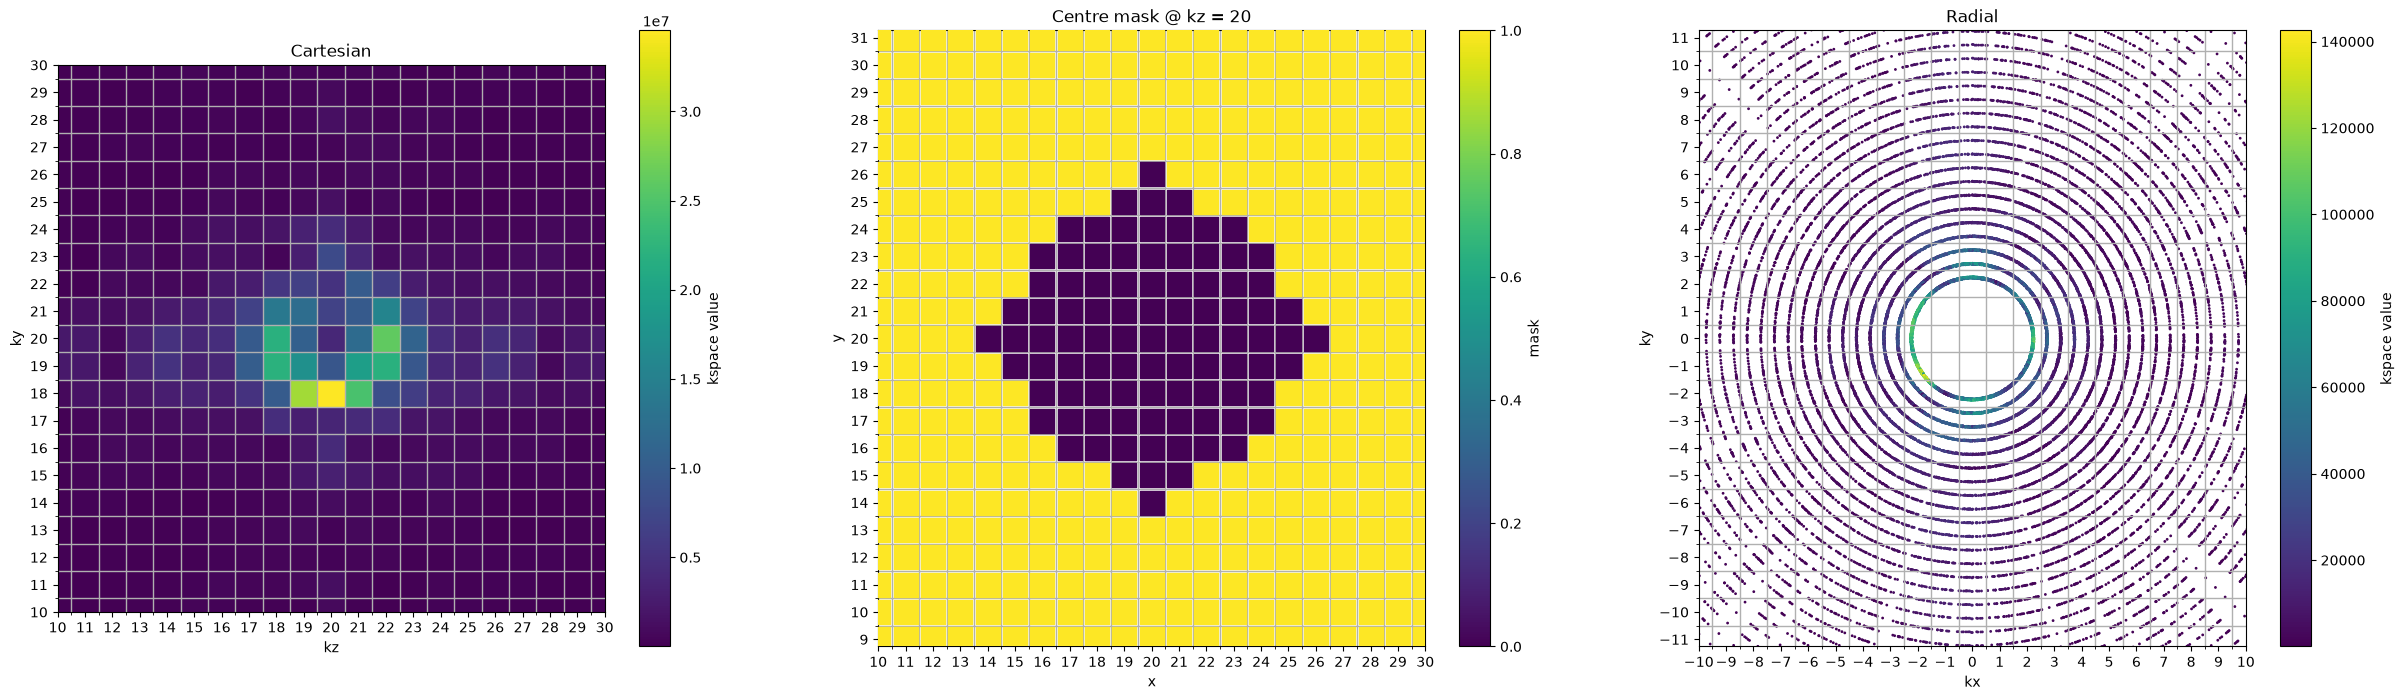

In [3]:
import matplotlib

all_ztecoords= coorlowres.reshape(-1,3)
all_zteksp = kspacelowres.reshape(-1)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))

grid_vol_zeropadding = np.abs(gridded_data[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2


im = ax[0].imshow(
    np.abs(grid_vol_zeropadding[kx_centre_large]),
    origin='lower',
    #norm=matplotlib.colors.LogNorm(),
)
fig.colorbar(im, ax=ax[0], label='kspace value')
ax[0].set_title('Cartesian')
ax[0].set_xlabel('kz')
ax[0].set_ylabel('ky')
ax[0].set_xlim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
ax[0].set_ylim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].grid(visible=True, which='minor', linewidth=1)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))




yy, xx = np.mgrid[0:mask2d.shape[0], 0:mask2d.shape[1]]
im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask2d.ravel().astype(int),
                    cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im1, ax=ax[1], label='mask')
ax[1].set_title(f'Centre mask @ kz = {cz}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].axis('equal')

c = mask2d.shape[0] / 2
ax[1].set_xlim(c - sidelencart, c + sidelencart)
ax[1].set_ylim(c - sidelencart, c + sidelencart)

ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].grid(visible=True, which='minor', linewidth=1)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))



tol = 0.5  # slab half-thickness; adjust to your coordinate units
maskzte = np.abs(all_ztecoords[:, 0]) < tol

im2 = ax[2].scatter(all_ztecoords[maskzte, 1], all_ztecoords[maskzte, 2],c=np.abs(kspacelowres[0]).reshape(-1)[maskzte],s=1)
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(-10,10)
ax[2].set_ylim(-10,10)

plt.show()

In [ ]:
n_iters = 2
window_size = 10
cartesian_inputkspace = inner_region
inner_mask = inner_mask
start = start
end = end
dtg_mask = mask
zeropadded = enlarged_cartesian
rank = 10
lamda = 5*10**-5
im_dim = 40

ksp_zerod = cartesian_inputkspace * dtg_mask
np.multiply(cartesian_inputkspace, dtg_mask,out=cartesian_inputkspace)
hankel_matrix = fy.hankel(kspace=ksp_zerod, w=window_size)
mask_coiled = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
masked_hankel = fy.hankel(kspace=mask_coiled.astype(np.float32), w=window_size) > 0.5

del ksp_zerod, mask_coiled
filled_hankel, t_total, t_mean, iter_times = fy.softimpute_ALS_time(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters)

kspace_cart_coils_recon = fy.hankel_H_averaged(filled_hankel, n_coils=cartesian_inputkspace.shape[0], Nx=cartesian_inputkspace.shape[1], Ny=cartesian_inputkspace.shape[2], Nz=cartesian_inputkspace.shape[3],w=window_size)
kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)

In [ ]:
iter_times

In [ ]:
output_kspace = kspace_cart_coils_recon.copy()
filled_ksp = asm.rebuild(output_kspace=output_kspace, inner_mask = inner_mask, inner_start = start, inner_end = end, enlarged_kspace=zeropadded, resize_x = im_dim, resize_y = im_dim)
im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

In [ ]:
import time

timings = {'als': [], 'svd': []}
t0 = time.perf_counter()
im_als, output_kspaceals, zeroed, total_time, mean_time, raw_times = fy.LORAKS_imputeals(n_iters=1, window_size=10, cartesian_inputkspace=inner_region, zeropadded = enlarged_cartesian,dtg_mask=mask, rank= 10, lamda = 5*10**-5, im_dim=256)
t1 = time.perf_counter()
timings['als'].append(t1 - t0)

print(f"Als done in {t1-t0}")



In [ ]:
t2 = time.perf_counter()
ims_svd, output_kspacesvd, deltas, svdtimes, hankelshape = fy.LORAKS_loop_timing(n_iters=2, window_size=5, zero_thresh=0.2,cartesian_inputkspace=inner_region, dtg_mask=mask, im_dim=256)
t3 = time.perf_counter()
#timings['svd'].append(t3-t2)

print(f"SVD done in {t3-t2}")

svdtimes_cleaned = {key: float(np.mean(times[1:])) for key, times in svdtimes.items()}

print(svdtimes_cleaned)
print(mean_time)

test_results = {'2 points removed':preloop, 'als, window:10 ,rank:10, lam:5e-5':im_als, 'svd, window:5, zerthresh:0.2': ims_svd,'nogap':img_nogap}

asm.diff_matrix(test_results, title=f'100 Iterations, Stride of 1.')